In [76]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn 
import torch.optim as optim
import copy
import re

In [77]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)

In [78]:
df = pd.read_csv('Cars Datasets.csv')

print(df.head())

  Company Names     Cars Names      Engines CC/Battery Capacity HorsePower  \
0       FERRARI  SF90 STRADALE           V8             3990 cc     963 hp   
1   ROLLS ROYCE        PHANTOM          V12             6749 cc     563 hp   
2          Ford            KA+  1.2L Petrol            1,200 cc   70-85 hp   
3      MERCEDES        GT 63 S           V8            3,982 cc     630 hp   
4          AUDI     AUDI R8 Gt          V10            5,204 cc     602 hp   

  Total Speed Performance(0 - 100 )KM/H      Cars Prices       Fuel Types  \
0    340 km/h                   2.5 sec       $1,100,000  plug in hyrbrid   
1    250 km/h                   5.3 sec         $460,000           Petrol   
2    165 km/h                  10.5 sec  $12,000-$15,000           Petrol   
3    250 km/h                   3.2 sec         $161,000           Petrol   
4    320 km/h                   3.6 sec         $253,290           Petrol   

   Seats        Torque  
0      2        800 Nm  
1      5        90

In [79]:
def clean_values(value):
    if pd.isna(value): return np.nan
    cleaned_str = re.sub(r'[^\d\.\-]', '', str(value)) #delete non numeric characters

    try:
        if '-' in cleaned_str: #use the mean of the interval for values containing -
            parts = cleaned_str.split('-')
            nums = [float(p) for p in parts if p]
            return sum(nums)/len(nums) if nums else np.nan
        else:
            return float(cleaned_str)
    except ValueError:
        return np.nan

In [80]:
# keep CC , Returns NaN for Electric (kWh)
def extract_engine_volume(value):
    if pd.isna(value): return np.nan
    val_str = str(value).lower().replace(',', '')
    
    if 'cc' in val_str:
        number = re.search(r'(\d+\.?\d*)', val_str)
        if number:
            return float(number.group(1))

    return np.nan

In [81]:
def simplify_engine(engine_str):
    if pd.isna(engine_str): return 'Unknown'
    engine_str = str(engine_str).upper()
    
    if 'ELECTRIC' in engine_str: return 'Electric'
    if 'V8' in engine_str or 'V12' in engine_str or 'V10' in engine_str or 'V6' in engine_str: return 'V-Engine'
    if 'I4' in engine_str or 'INLINE-4' in engine_str or 'I3' in engine_str: return 'Inline-Engine'
    if 'HYBRID' in engine_str: return 'Hybrid'
    return 'Other'

In [82]:
class standardScaler:
    def __init__(self):
        self.mean = None
        self.std = None
        
    def fit(self, X):
        X = np.array(X, dtype=np.float64) 
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        
        if np.isscalar(self.std):
            if self.std == 0:
                self.std = 1.0
        else:
            self.std = np.where(self.std == 0, 1.0, self.std)
        return self

    def transform(self, X):
        X = np.array(X, dtype=np.float64) 
        return (X - self.mean) / self.std
    
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [83]:
def train_test_split(X, y, train_ratio=0.7, val_ratio=0.15, random_state=42):
    np.random.seed(random_state)
    n_samples = X.shape[0]

    indices = np.random.permutation(n_samples)

    split_idx1 = int(train_ratio * n_samples)
    split_idx2 = int((train_ratio+val_ratio) * n_samples)

    train_idx = indices[:split_idx1]
    val_idx = indices[split_idx1:split_idx2]
    test_idx = indices[split_idx2:]

    return (X.iloc[train_idx], y.iloc[train_idx], 
            X.iloc[val_idx], y.iloc[val_idx], 
            X.iloc[test_idx], y.iloc[test_idx])

In [84]:
df['CC/Battery Capacity'] = df['CC/Battery Capacity'].apply(extract_engine_volume)
df['Engines'] = df['Engines'].apply(simplify_engine)

cols_to_clean = ['Cars Prices', 'HorsePower', 'Total Speed', 'Performance(0 - 100 )KM/H', 'Torque']

for col in cols_to_clean:
    df[col] = df[col].apply(clean_values)

df = df.dropna(subset=['Cars Prices'])
df = df.reset_index(drop=True)

target_col = 'Cars Prices'

#delete car name
selected_features = ['Company Names', 'Engines','CC/Battery Capacity', 'HorsePower', 'Torque', 'Fuel Types', 'Performance(0 - 100 )KM/H', 'Total Speed', 'Seats', 'Cars Prices']

numeric_cols = ['CC/Battery Capacity','Performance(0 - 100 )KM/H', 'HorsePower', 'Torque', 'Total Speed', 'Seats']

categorical_cols = ['Company Names', 'Engines', 'Fuel Types']

data = df[selected_features + [target_col]].copy()

# fill numeric null values with mean
for col in numeric_cols:
    data[col] = data[col].fillna(data[col].mean())

# fill categorical null values with Unknown
for col in categorical_cols:
    data[col] = data[col].fillna('Unknown')

In [85]:
X = data.drop(columns=[target_col])
y = data[target_col].iloc[:, 0]

X_train, y_train, X_val, y_val, X_test, y_test = train_test_split(X, y, train_ratio=0.7, val_ratio=0.15, random_state=42)

In [86]:
processed_data = {
    'OneHot': {},
    'Target': {},
    'Embedding': {}
}

1. One-hot Encoding

In [87]:
#one hot encoding, creating cols like Fuel-Petrol and Fuel-Diesel
X_train_ohe = pd.get_dummies(X_train, columns=categorical_cols, dummy_na=False)
X_val_ohe = pd.get_dummies(X_val, columns=categorical_cols, dummy_na=False)
X_test_ohe = pd.get_dummies(X_test, columns=categorical_cols, dummy_na=False)

#if a value exists in train but not in val, fill it with 0, but if it was not in train, delete it. 
X_val_ohe = X_val_ohe.reindex(columns=X_train_ohe.columns, fill_value=0)
X_test_ohe = X_test_ohe.reindex(columns=X_train_ohe.columns, fill_value=0)

processed_data['OneHot'] = (X_train_ohe, X_val_ohe, X_test_ohe)
print("One-Hot Encoding Finished. Shape:", X_train_ohe.shape)

One-Hot Encoding Finished. Shape: (851, 66)


2. Target encoding

In [88]:
X_train_te = X_train.copy()
X_val_te = X_val.copy()
X_test_te = X_test.copy()

global_mean = y_train.mean()

for col in categorical_cols:
    mapping = y_train.groupby(X_train[col]).mean()
    #با میانگین تارگتش پر میکنیم
    X_train_te[col] = X_train_te[col].map(mapping)
    X_val_te[col] = X_val_te[col].map(mapping).fillna(global_mean)
    X_test_te[col] = X_test_te[col].map(mapping).fillna(global_mean)

processed_data['Target'] = (X_train_te, X_val_te, X_test_te)
print("Target Encoding Finished. Shape:", X_train_te.shape)


Target Encoding Finished. Shape: (851, 9)


3. Label Encoding

In [89]:
X_train_le = X_train.copy()
X_val_le = X_val.copy()
X_test_le = X_test.copy()

embedding_info = {}

for col in categorical_cols:
    unique_vals = X_train[col].unique()
    val_to_int = {val: i for i, val in enumerate(unique_vals)}
    
    unknown_idx = len(unique_vals)
    
    def safe_mapper(val):
        return val_to_int.get(val, unknown_idx)
    
    X_train_le[col] = X_train_le[col].apply(safe_mapper)
    X_val_le[col] = X_val_le[col].apply(safe_mapper)
    X_test_le[col] = X_test_le[col].apply(safe_mapper)
    
    embedding_info[col] = len(unique_vals) + 1

processed_data['Embedding'] = (X_train_le, X_val_le, X_test_le)
print("Label Encoding Finished. Shape:", X_train_le.shape)


Label Encoding Finished. Shape: (851, 9)


Scaling

In [90]:
scaler_y = standardScaler()
#convert to 2D array:
y_train_arr = y_train.values.reshape(-1, 1)
y_val_arr = y_val.values.reshape(-1, 1)
y_test_arr = y_test.values.reshape(-1, 1)

y_train_scaled = scaler_y.fit_transform(y_train_arr)
y_val_scaled = scaler_y.transform(y_val_arr)
y_test_scaled = scaler_y.transform(y_test_arr)

final_datasets = {}

for method, (tr, val, te) in processed_data.items():
    scaler_X = standardScaler()
    
    if method == 'Embedding':
        #only scaling numeric cols
        tr_sc = tr.copy()
        val_sc = val.copy()
        te_sc = te.copy()
        
        tr_sc[numeric_cols] = scaler_X.fit_transform(tr[numeric_cols])
        val_sc[numeric_cols] = scaler_X.transform(val[numeric_cols])
        te_sc[numeric_cols] = scaler_X.transform(te[numeric_cols])
        
        final_datasets[method] = (tr_sc, val_sc, te_sc)
        
    else:
        tr_scaled = scaler_X.fit_transform(tr)
        val_scaled = scaler_X.transform(val)
        te_scaled = scaler_X.transform(te)
        final_datasets[method] = (tr_scaled, val_scaled, te_scaled)

In [91]:
#convert numpy data to pytorch tensor
tensor_datasets = {}

for method_name, (X_tr, X_v, X_te) in final_datasets.items():
    X_tr_t = torch.tensor(np.array(X_tr), dtype=torch.float32)
    X_v_t = torch.tensor(np.array(X_v), dtype=torch.float32)
    X_te_t = torch.tensor(np.array(X_te), dtype=torch.float32)

    tensor_datasets[method_name] = (X_tr_t, X_v_t, X_te_t)

y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

Architecture

In [92]:
class MLP(nn.Module):
    def __init__(self, input_size, dropout_rate=0.0):
        super(MLP, self).__init__()

        self.layer1 = nn.Linear(input_size, 64)
        self.layer2 = nn.Linear(64, 32)
        self.layer3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        out = self.relu(self.layer1(x))
        out = self.dropout(out)

        out = self.relu(self.layer2(out))
        out = self.dropout(out)

        out = self.layer3(out)
        return out

In [93]:
class MLPEmbedded(nn.Module):
    def __init__(self, embedding_sizes, n_cont, dropout_rate=0.0):
        super(MLPEmbedded, self).__init__()
        
        self.n_cont = n_cont
        #create Embedding layer
        self.embeddings = nn.ModuleList([
            nn.Embedding(categories, size) for categories, size in embedding_sizes
        ])
        #calculate input size: Embedding sizes + numeric cols number
        self.n_emb = sum(e.embedding_dim for e in self.embeddings)
        self.input_dim = self.n_emb + self.n_cont

        self.layer1 = nn.Linear(self.input_dim, 64)
        self.layer2 = nn.Linear(64, 32)
        self.layer3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)


    def forward(self, x_cat, x_cont):
        #processing the categorical:
        x = [e(x_cat[:, i]) for i, e in enumerate(self.embeddings)]
        x = torch.cat(x, 1)
        
        #processing the numeric:
        x = torch.cat([x, x_cont], 1)
        x = self.relu(self.layer1(x))
        x = self.dropout(x)

        x = self.relu(self.layer2(x))
        x = self.dropout(x)
        
        x = self.layer3(x)
        return x

In [94]:
X_train_emb, X_val_emb, X_test_emb = tensor_datasets['Embedding']

# splitting categ. cols and num. cols using their indices
cat_idxs = [X_train.columns.get_loc(c) for c in categorical_cols]
cont_idxs = [X_train.columns.get_loc(c) for c in numeric_cols]

def split_cat_cont(X_tensor):
    cats = X_tensor[:, cat_idxs].long()
    conts = X_tensor[:, cont_idxs].float()
    return cats, conts

X_train_cat, X_train_cont = split_cat_cont(X_train_emb)
X_val_cat, X_val_cont = split_cat_cont(X_val_emb)

embedding_sizes = [(n_cats, min(50, (n_cats+1)//2)) for col, n_cats in embedding_info.items()]

In [95]:
def train_model(
        X_train, y_train, X_val, y_val,
        model_type = 'standard', #we have 2 models: standard or embedding
        embedding_sizes = None, n_cont = 0,
        config = 'A', #we have 4 configs: A, B, C, D
        optimizer_name = 'Adam',
        lr = 0.001,
        dropout_rate = 0.0,
        epochs = 200
):
    input_dim = X_train.shape[1] if model_type == 'standard' else 0
    current_dropout = 0.3 if config == 'B' else dropout_rate

    if model_type == 'standard':
        model = MLP(input_dim, dropout_rate=current_dropout)
    else: 
        model = MLPEmbedded(embedding_sizes, n_cont, dropout_rate=current_dropout)

    
    if optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == 'RMSProp':
        optimizer = optim.RMSprop(model.parameters(), lr=lr)


    criterion = nn.MSELoss()

    #defining vars related to Early stopping and LR Decay:
    best_val_loss = float('inf')
    patience_counter = 0
    decay_counter = 0
    decay_patience_counter = 0
    best_model_wts = copy.deepcopy(model.state_dict())

    train_hist = []
    val_hist = []

    #preprocessing data for Embedding model:
    if model_type == 'embedding':
        X_tr_cat, X_tr_cont = split_cat_cont(X_train)
        X_val_cat, X_val_cont = split_cat_cont(X_val)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        if model_type == 'standard':
            out = model(X_train)
        else:
            out = model(X_tr_cat, X_tr_cont)

        loss = criterion(out, y_train)
        loss.backward()
        optimizer.step()

        train_rmse = torch.sqrt(loss).item()
        train_hist.append(train_rmse)
        
        #Validation:
        model.eval()
        with torch.no_grad():
            if model_type == 'standard':
                val_out = model(X_val)
            else:
                val_out = model(X_val_cat, X_val_cont)

            val_loss = criterion(val_out, y_val)
            val_rmse = torch.sqrt(val_loss).item()
            val_hist.append(val_rmse)

        #check controling logic:
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
            decay_patience_counter = 0
        else: 
            patience_counter += 1
            decay_patience_counter += 1
        
        if config == 'C':
            if patience_counter >= 10:
                print(f"Early stopping at epoch {epoch+1}")
                model.load_state_dict(best_model_wts)
                break
        
        if config == 'D':
            if decay_patience_counter >= 5 and decay_counter < 3:
                decay_counter += 1
                decay_patience_counter = 0

                for param_group in optimizer.param_groups:
                    param_group['lr'] *= 0.5
                print(f"Decaying LR to {optimizer.param_groups[0]['lr']} at epoch {epoch+1}")

    if config == 'C':
         model.load_state_dict(best_model_wts)

    return train_hist, val_hist, min(val_hist)

task 1 - compare Methods

--- Starting Task 1 (Encoding Methods) ---
Training with OneHot...
Best Val loss using OneHot = 0.1446
Training with Target...
Best Val loss using Target = 0.0818
Training with Embedding...
Best Val loss using Embedding = 0.0451


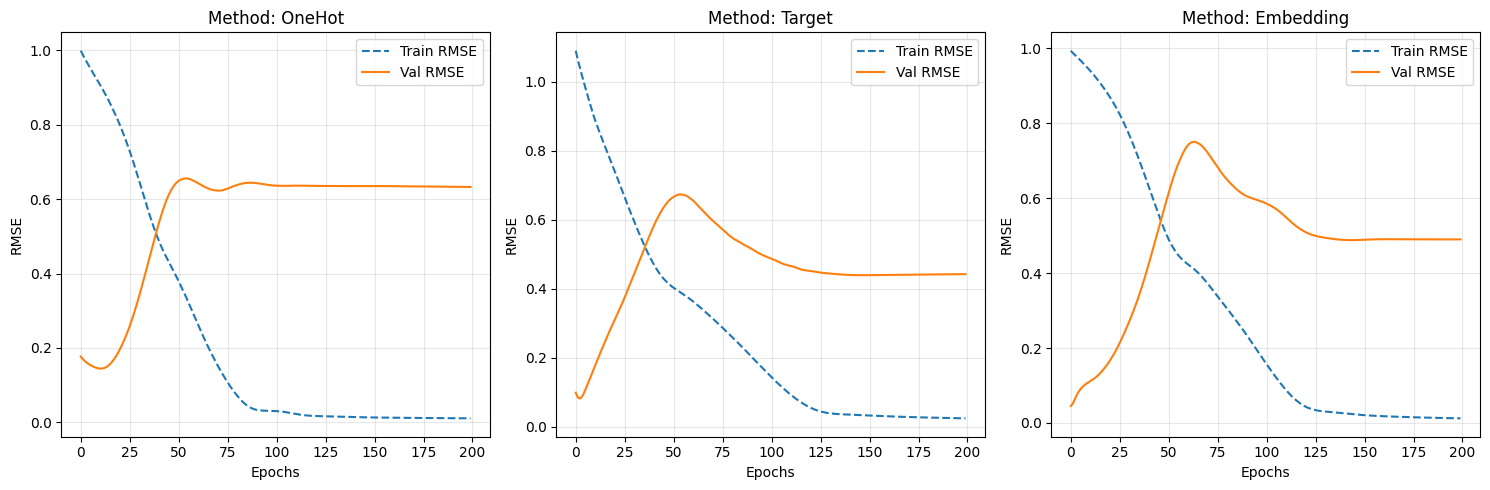

In [96]:
results_task1 = {}
methods = ['OneHot', 'Target', 'Embedding']

print("--- Starting Task 1 (Encoding Methods) ---")

for method in methods:
    print(f"Training with {method}...")
    X_tr, X_v, _ = tensor_datasets[method]
    
    if method == 'Embedding':
        tr_hist, val_hist, best_rmse = train_model(
            X_tr, y_train_tensor, X_v, y_val_tensor,
            model_type='embedding',
            embedding_sizes=embedding_sizes,
            n_cont=len(numeric_cols),
            config='A',
            lr=0.001
        )
    else:
        tr_hist, val_hist, best_rmse = train_model(
            X_tr, y_train_tensor, X_v, y_val_tensor,
            model_type='standard',
            config='A',
            lr=0.001
        )

    best_rmse = min(val_hist)
    print(f"Best Val loss using {method} = {best_rmse:.4f}") 
    results_task1[method] = (tr_hist, val_hist, best_rmse)

plt.figure(figsize=(15, 5))

for i, method in enumerate(methods):
    tr, val, _ = results_task1[method]
    plt.subplot(1, 3, i+1)
    plt.plot(tr, label='Train RMSE', linestyle='--')
    plt.plot(val, label='Val RMSE')
    plt.title(f"Method: {method}")
    plt.xlabel("Epochs")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

task 2 - compare configs

--- Starting Task 2 (A, B, C, D configs) ---
Running: Method=OneHot, Config=A
Best Val loss using OneHot and config A = 0.1640
Running: Method=OneHot, Config=B
Best Val loss using OneHot and config B = 0.0708
Running: Method=OneHot, Config=C
Early stopping at epoch 27
Best Val loss using OneHot and config C = 0.1000
Running: Method=OneHot, Config=D
Decaying LR to 0.0005 at epoch 6
Decaying LR to 0.00025 at epoch 11
Decaying LR to 0.000125 at epoch 16
Best Val loss using OneHot and config D = 0.1186
Running: Method=Target, Config=A
Best Val loss using Target and config A = 0.1495
Running: Method=Target, Config=B
Best Val loss using Target and config B = 0.0619
Running: Method=Target, Config=C
Early stopping at epoch 24
Best Val loss using Target and config C = 0.0759
Running: Method=Target, Config=D
Decaying LR to 0.0005 at epoch 17
Decaying LR to 0.00025 at epoch 22
Decaying LR to 0.000125 at epoch 27
Best Val loss using Target and config D = 0.1722
Running: Method=Embedding, Config=A


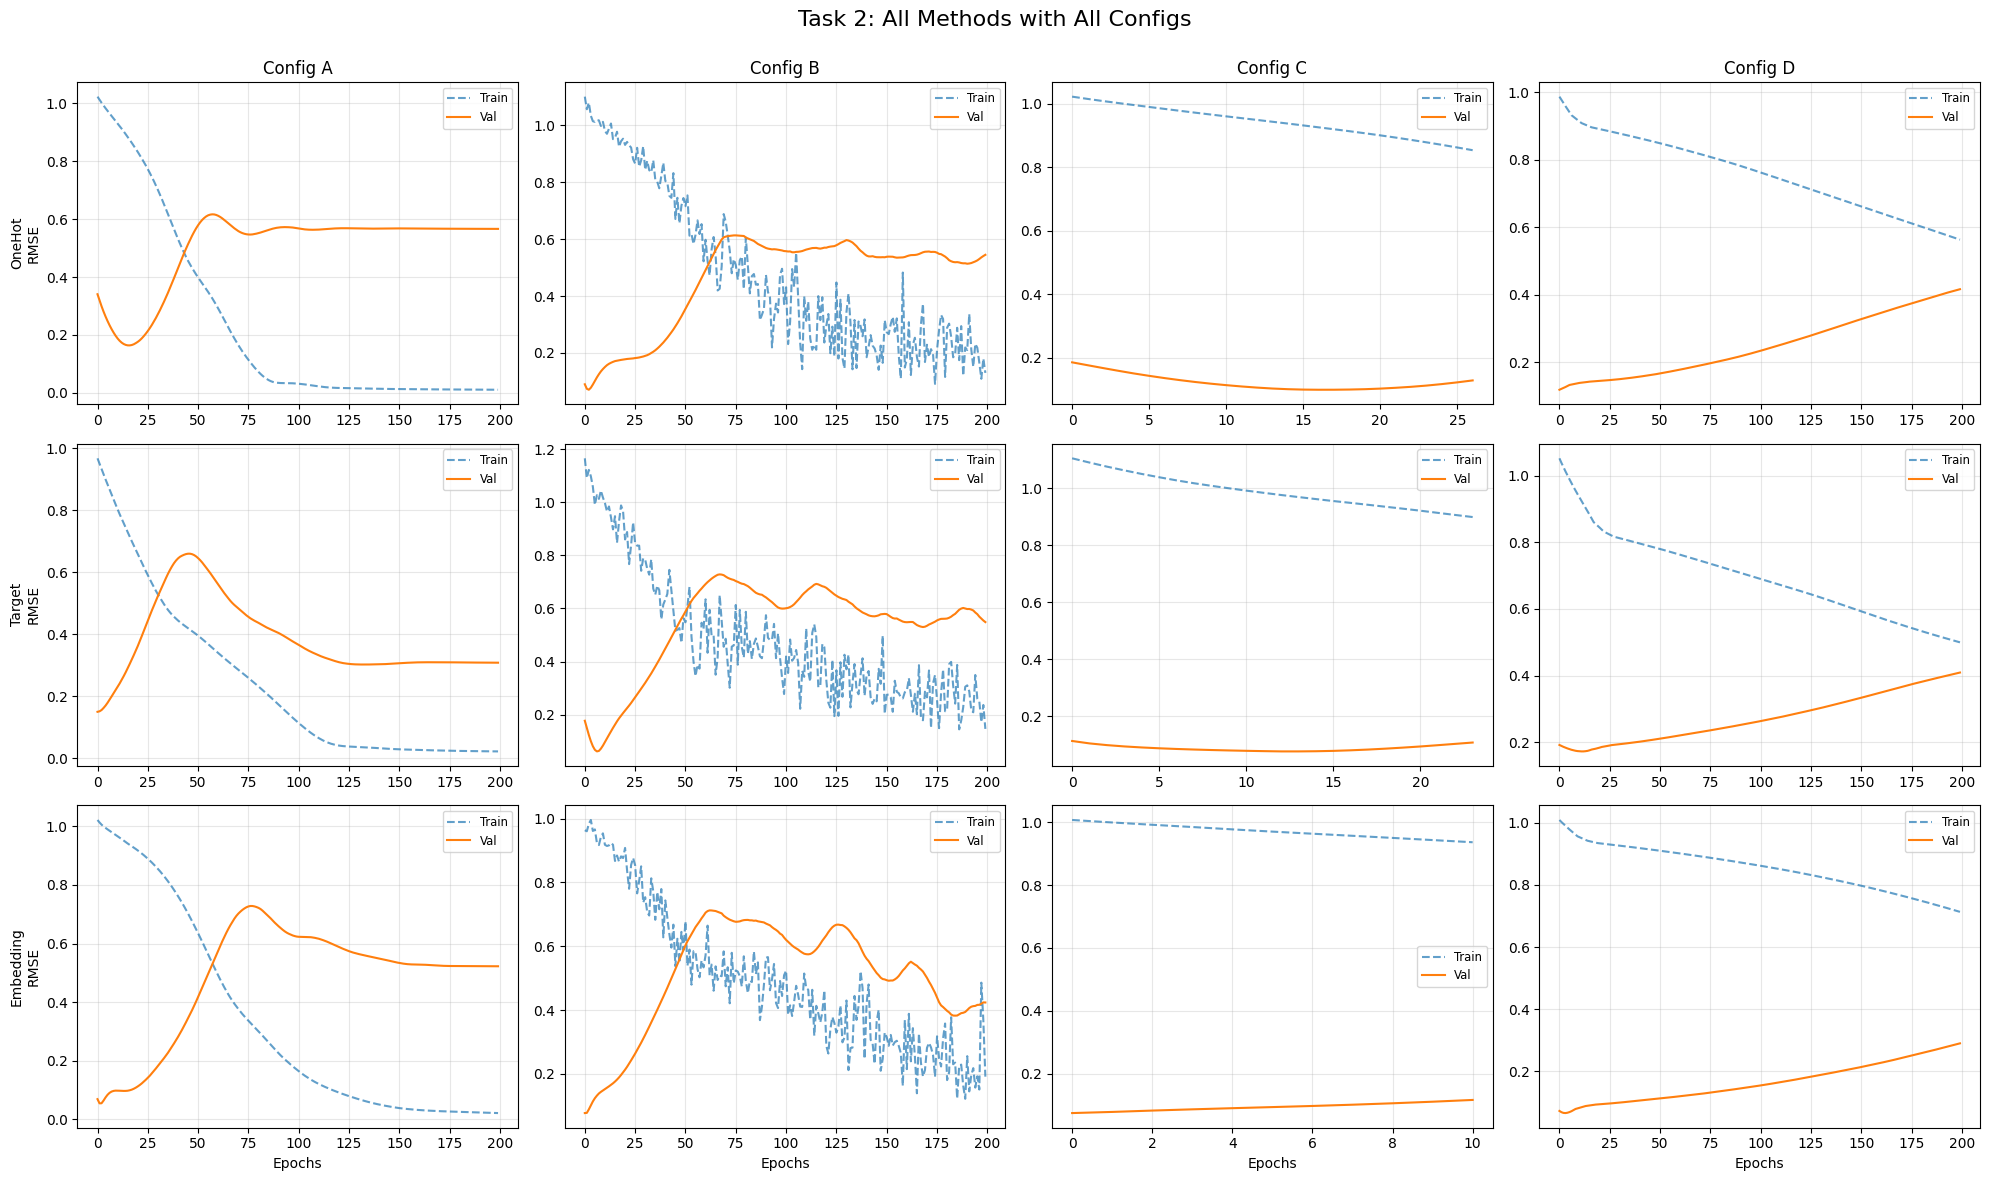

In [97]:
configs = ['A', 'B', 'C', 'D']
encoding_methods = ['OneHot', 'Target', 'Embedding']
results_task2 = {m: {} for m in methods}

print("--- Starting Task 2 (A, B, C, D configs) ---")
for method in encoding_methods:
    X_tr, X_v, _ = tensor_datasets[method]

    for conf in configs:
        print(f"Running: Method={method}, Config={conf}")
        if method == 'Embedding':
             tr_hist, val_hist, best_rmse = train_model(
                X_tr, y_train_tensor, X_v, y_val_tensor,
                model_type='embedding',
                embedding_sizes=embedding_sizes,
                n_cont=len(numeric_cols),
                config=conf,
                lr=0.001
            )
        else:
            tr_hist, val_hist, best_rmse = train_model(
                X_tr, y_train_tensor, X_v, y_val_tensor,
                model_type='standard',
                config=conf,
                lr=0.001
            )

        results_task2[method][conf] = (tr_hist, val_hist)
        best_rmse = min(val_hist)
        print(f"Best Val loss using {method} and config {conf} = {best_rmse:.4f}")

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle("Task 2: All Methods with All Configs", fontsize=16)

for i, method in enumerate(methods):
    for j, conf in enumerate(configs):
        tr, val = results_task2[method][conf]
        ax = axes[i, j]
        
        ax.plot(tr, label='Train', linestyle='--', alpha=0.7)
        ax.plot(val, label='Val')
        
        if i == 0: ax.set_title(f"Config {conf}")
        if j == 0: ax.set_ylabel(f"{method}\nRMSE")
        
        ax.grid(True, alpha=0.3)
        if i == 2: ax.set_xlabel("Epochs")
        ax.legend(fontsize='small')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

task 3 - compare optimizers


--- Starting Task 3 (Optimizers) ---
Testing Optimizer: Adam
Decaying LR to 0.0005 at epoch 18
Decaying LR to 0.00025 at epoch 23
Decaying LR to 0.000125 at epoch 28
Testing Optimizer: SGD
Decaying LR to 0.0005 at epoch 6
Decaying LR to 0.00025 at epoch 11
Decaying LR to 0.000125 at epoch 16
Testing Optimizer: RMSProp
Decaying LR to 0.0005 at epoch 6
Decaying LR to 0.00025 at epoch 11
Decaying LR to 0.000125 at epoch 16


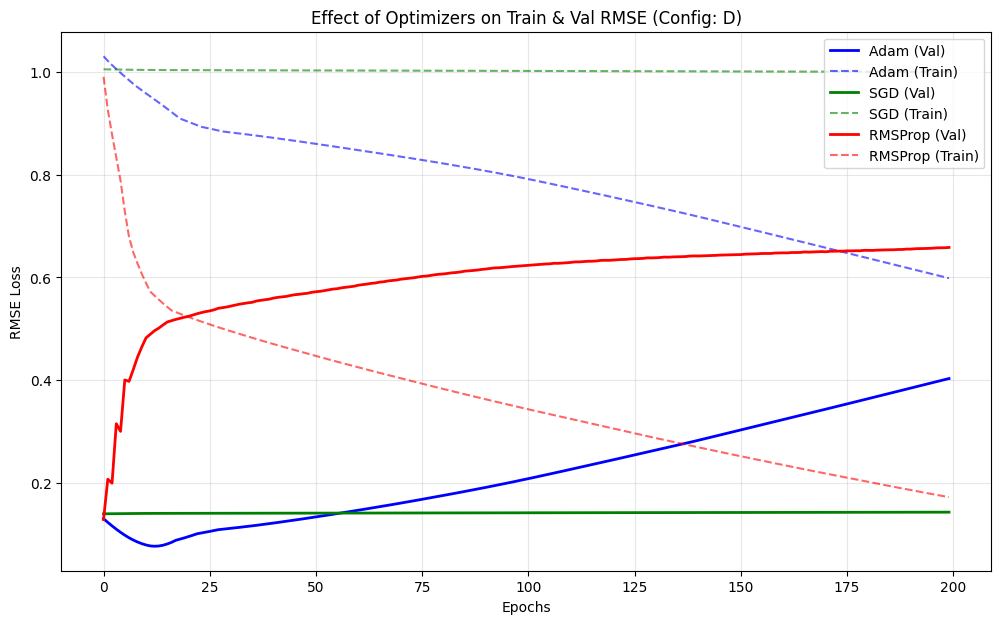

In [98]:
optimizers = ['Adam', 'SGD', 'RMSProp']
results_task3 = {}

best_method = 'OneHot'
best_config = 'D'
X_tr, X_v, _ = tensor_datasets[best_method]

print("\n--- Starting Task 3 (Optimizers) ---")

for opt in optimizers:
    print(f"Testing Optimizer: {opt}")
    tr_hist, val_hist, best_rmse = train_model(
        X_tr, y_train_tensor, X_v, y_val_tensor,
        model_type='standard',
        config=best_config,
        optimizer_name=opt,
        lr=0.001
    )
    results_task3[opt] = (tr_hist, val_hist)

plt.figure(figsize=(12, 7))
color_map = {'Adam': 'blue', 'SGD': 'green', 'RMSProp': 'red'}

for opt in optimizers:
    tr_hist, val_hist = results_task3[opt]
    c = color_map[opt]
    plt.plot(val_hist, label=f'{opt} (Val)', color=c, linestyle='-', linewidth=2)
    plt.plot(tr_hist, label=f'{opt} (Train)', color=c, linestyle='--', alpha=0.6)

plt.title(f"Effect of Optimizers on Train & Val RMSE (Config: {best_config})")
plt.xlabel("Epochs")
plt.ylabel("RMSE Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

task 4 - compare Hyperparameters


--- Starting Task 4 (Hyperparameters) ---

Varying Learning Rate (Fixed Dropout=0.3)
Training with Learning rate=0.0001...
Decaying LR to 5e-05 at epoch 71
Decaying LR to 2.5e-05 at epoch 76
Decaying LR to 1.25e-05 at epoch 81
Training with Learning rate=0.0005...
Decaying LR to 0.00025 at epoch 34
Decaying LR to 0.000125 at epoch 39
Decaying LR to 6.25e-05 at epoch 44
Training with Learning rate=0.001...
Decaying LR to 0.0005 at epoch 11
Decaying LR to 0.00025 at epoch 16
Decaying LR to 0.000125 at epoch 21
Training with Learning rate=0.005...
Decaying LR to 0.0025 at epoch 6
Decaying LR to 0.00125 at epoch 11
Decaying LR to 0.000625 at epoch 16
Training with Learning rate=0.01...
Decaying LR to 0.005 at epoch 7
Decaying LR to 0.0025 at epoch 12
Decaying LR to 0.00125 at epoch 17

Varying Dropout Rate (Fixed LR=0.001)
Training with Dropout=0.0...
Training with Dropout=0.1...
Training with Dropout=0.2...
Training with Dropout=0.3...
Training with Dropout=0.4...


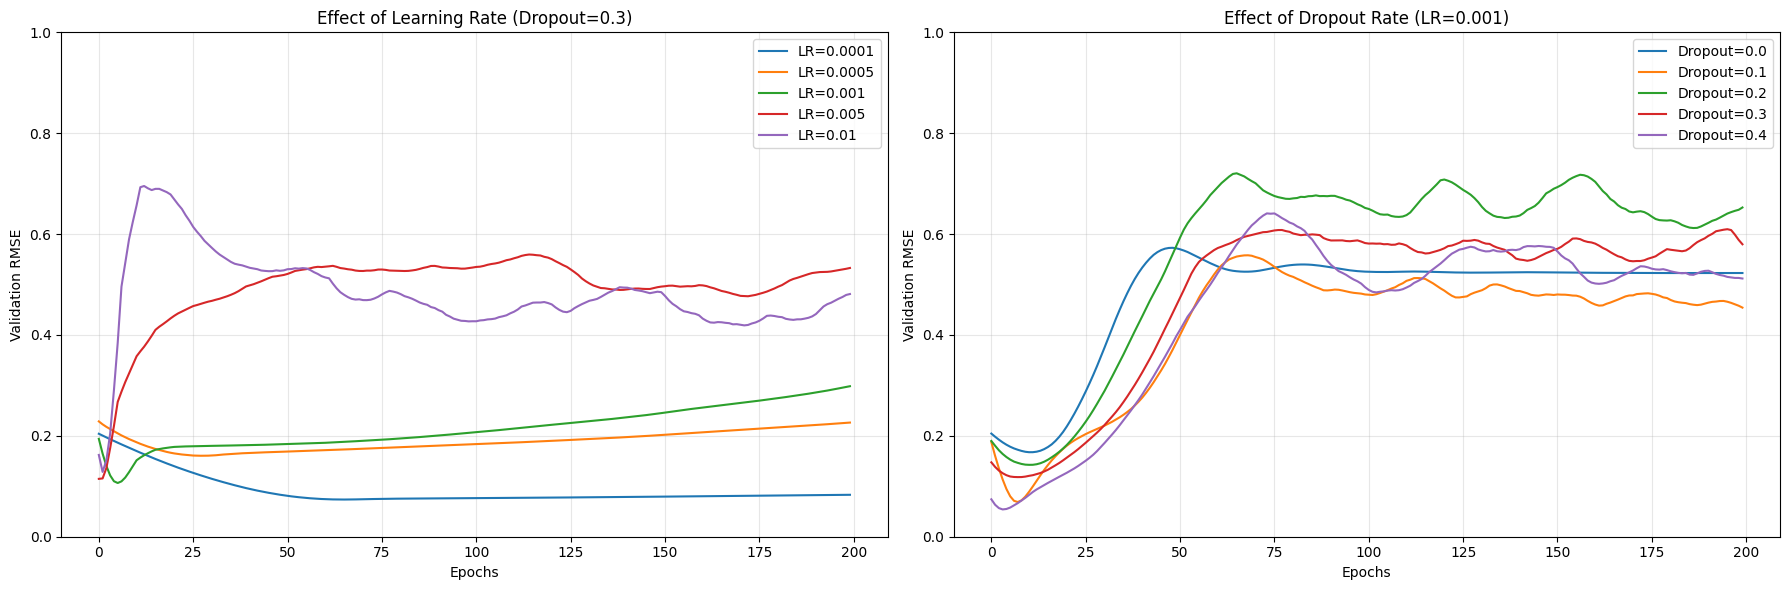

In [99]:
learning_rates = [0.0001, 0.0005, 0.001, 0.005, 0.01]
dropout_rates = [0.0, 0.1, 0.2, 0.3, 0.4]

FIXED_DROPOUT = 0.3
FIXED_LR = 0.001

results_lr_analysis = {}
results_dropout_analysis = {}

print("\n--- Starting Task 4 (Hyperparameters) ---")
print(f"\nVarying Learning Rate (Fixed Dropout={FIXED_DROPOUT})")
for i, lr in enumerate(learning_rates):    
    print(f"Training with Learning rate={lr}...")
    _, val_hist, best_rmse = train_model(
        X_tr, y_train_tensor, X_v, y_val_tensor,
        model_type='standard',
        config=best_config,
        optimizer_name='Adam',
        lr=lr,
        dropout_rate=FIXED_DROPOUT,
        epochs=200
    )
    results_lr_analysis[lr] = val_hist

print(f"\nVarying Dropout Rate (Fixed LR={FIXED_LR})")
for dr in dropout_rates:
    print(f"Training with Dropout={dr}...")
    tr_hist, val_hist, _ = train_model(
        X_tr, y_train_tensor, X_v, y_val_tensor,
        model_type='standard',
        config='A',
        optimizer_name='Adam',
        lr=FIXED_LR,
        dropout_rate=dr,
        epochs=200
    )
    results_dropout_analysis[dr] = val_hist


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

for lr, hist in results_lr_analysis.items():
    ax1.plot(hist, label=f"LR={lr}")
ax1.set_title(f"Effect of Learning Rate (Dropout={FIXED_DROPOUT})")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Validation RMSE")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.0) 

for dr, hist in results_dropout_analysis.items():
    ax2.plot(hist, label=f"Dropout={dr}")
ax2.set_title(f"Effect of Dropout Rate (LR={FIXED_LR})")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Validation RMSE")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()